In [1]:
# Import pandas library for data manipulation
import pandas as pd

# Import numpy library for numerical operations
import numpy as np

# Load the Airline Passenger Satisfaction dataset
df = pd.read_csv("../data/raw/Airline_Passenger_Satisfaction.csv")

# Display the first 5 rows
df.head()

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Departure Delay in Minutes,Arrival Delay in Minutes,Inflight wifi service,Departure/Arrival time convenient,...,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,satisfaction
0,Male,Loyal Customer,49,Business travel,Business,219,12,14,3,2,...,2,2,2,2,4,1,1,4,4,satisfied
1,Female,Loyal Customer,39,Business travel,Eco,4852,16,13,2,2,...,1,4,2,5,4,3,5,1,1,neutral or dissatisfied
2,Female,Loyal Customer,56,Personal Travel,Eco Plus,3891,8,16,4,4,...,5,4,1,1,4,4,2,4,4,satisfied
3,Male,Loyal Customer,75,Business travel,Business,3194,12,31,3,4,...,2,1,5,5,1,4,2,5,4,satisfied
4,Male,Loyal Customer,23,Business travel,Business,3778,13,0,1,5,...,1,1,1,4,2,4,2,3,4,neutral or dissatisfied


In [2]:
# Check the number of rows and columns
print("Dataset Shape:", df.shape)

Dataset Shape: (130000, 23)


In [3]:
# Display all column names
print("Column Names:")
print(df.columns.tolist())

Column Names:
['Gender', 'Customer Type', 'Age', 'Type of Travel', 'Class', 'Flight Distance', 'Departure Delay in Minutes', 'Arrival Delay in Minutes', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness', 'satisfaction']


In [4]:
# Display information about columns, data types, and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 130000 entries, 0 to 129999
Data columns (total 23 columns):
 #   Column                             Non-Null Count   Dtype 
---  ------                             --------------   ----- 
 0   Gender                             130000 non-null  object
 1   Customer Type                      130000 non-null  object
 2   Age                                130000 non-null  int64 
 3   Type of Travel                     130000 non-null  object
 4   Class                              130000 non-null  object
 5   Flight Distance                    130000 non-null  int64 
 6   Departure Delay in Minutes         130000 non-null  int64 
 7   Arrival Delay in Minutes           130000 non-null  int64 
 8   Inflight wifi service              130000 non-null  int64 
 9   Departure/Arrival time convenient  130000 non-null  int64 
 10  Ease of Online booking             130000 non-null  int64 
 11  Gate location                      130000 non-null  

In [5]:
# Count missing values in each column
missing_values = df.isnull().sum()

# Display only columns that contain missing values
print("Missing Values:")
print(missing_values[missing_values > 0])

Missing Values:
Series([], dtype: int64)


In [6]:
# Remove unnecessary index columns if they exist
columns_to_drop = ['Unnamed: 0', 'id']

# Drop only the columns that are actually present in the dataset
df.drop(
    columns=[col for col in columns_to_drop if col in df.columns],
    inplace=True
)

# Display the remaining columns
print("Columns after removing unnecessary columns:")
print(df.columns.tolist())

Columns after removing unnecessary columns:
['Gender', 'Customer Type', 'Age', 'Type of Travel', 'Class', 'Flight Distance', 'Departure Delay in Minutes', 'Arrival Delay in Minutes', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness', 'satisfaction']


In [7]:
# Count duplicate rows
print("Duplicate rows before cleaning:", df.duplicated().sum())

Duplicate rows before cleaning: 0


In [8]:
# Remove duplicate rows from the dataset
df.drop_duplicates(inplace=True)

# Check duplicate rows again
print("Duplicate rows after cleaning:", df.duplicated().sum())

Duplicate rows after cleaning: 0


In [9]:
# Select all numerical columns
numeric_columns = df.select_dtypes(include=np.number).columns

# Fill missing numerical values with the median
for col in numeric_columns:
    df[col] = df[col].fillna(df[col].median())

In [10]:
# Select all categorical columns
categorical_columns = df.select_dtypes(include='object').columns

# Fill missing categorical values with the most frequent value (mode)
for col in categorical_columns:
    df[col] = df[col].fillna(df[col].mode()[0])

In [11]:
# Remove extra spaces from column names
df.columns = df.columns.str.strip()

# Convert column names to lowercase
df.columns = df.columns.str.lower()

# Replace spaces with underscores
df.columns = df.columns.str.replace(' ', '_')

# Display cleaned column names
print(df.columns.tolist())

['gender', 'customer_type', 'age', 'type_of_travel', 'class', 'flight_distance', 'departure_delay_in_minutes', 'arrival_delay_in_minutes', 'inflight_wifi_service', 'departure/arrival_time_convenient', 'ease_of_online_booking', 'gate_location', 'food_and_drink', 'online_boarding', 'seat_comfort', 'inflight_entertainment', 'on-board_service', 'leg_room_service', 'baggage_handling', 'checkin_service', 'inflight_service', 'cleanliness', 'satisfaction']


In [12]:
# Display the data type of every column
print("Data Types:")
print(df.dtypes)

Data Types:
gender                               object
customer_type                        object
age                                   int64
type_of_travel                       object
class                                object
flight_distance                       int64
departure_delay_in_minutes            int64
arrival_delay_in_minutes              int64
inflight_wifi_service                 int64
departure/arrival_time_convenient     int64
ease_of_online_booking                int64
gate_location                         int64
food_and_drink                        int64
online_boarding                       int64
seat_comfort                          int64
inflight_entertainment                int64
on-board_service                      int64
leg_room_service                      int64
baggage_handling                      int64
checkin_service                       int64
inflight_service                      int64
cleanliness                           int64
satisfaction        

In [13]:
# Save the cleaned dataset as a new CSV file
df.to_csv(
    "../data/processed/Airline_Passenger_Satisfaction_Cleaned.csv",
    index=False
)

# Display confirmation message
print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


## Create meaningful visualizations using Matplotlib, Seaborn, or Plotly. Design bar charts, line charts, pie charts, histograms, and scatter plots.

In [14]:
# Import pandas for data handling
import pandas as pd

# Import matplotlib for creating charts
import matplotlib.pyplot as plt

# Import seaborn for attractive statistical visualizations
import seaborn as sns

# Set the visual style
sns.set_style("whitegrid")

In [15]:
# Load the cleaned Airline Passenger Satisfaction dataset
df = pd.read_csv(
    "../data/processed/Airline_Passenger_Satisfaction_Cleaned.csv"
)

# Display first 5 rows
df.head()

,gender,customer_type,age,type_of_travel,class,flight_distance,departure_delay_in_minutes,arrival_delay_in_minutes,inflight_wifi_service,departure/arrival_time_convenient,...,online_boarding,seat_comfort,inflight_entertainment,on-board_service,leg_room_service,baggage_handling,checkin_service,inflight_service,cleanliness,satisfaction
0,Male,Loyal Customer,49,Business travel,Business,219,12,14,3,2,...,2,2,2,2,4,1,1,4,4,satisfied
1,Female,Loyal Customer,39,Business travel,Eco,4852,16,13,2,2,...,1,4,2,5,4,3,5,1,1,neutral or dissatisfied
2,Female,Loyal Customer,56,Personal Travel,Eco Plus,3891,8,16,4,4,...,5,4,1,1,4,4,2,4,4,satisfied
3,Male,Loyal Customer,75,Business travel,Business,3194,12,31,3,4,...,2,1,5,5,1,4,2,5,4,satisfied
4,Male,Loyal Customer,23,Business travel,Business,3778,13,0,1,5,...,1,1,1,4,2,4,2,3,4,neutral or dissatisfied


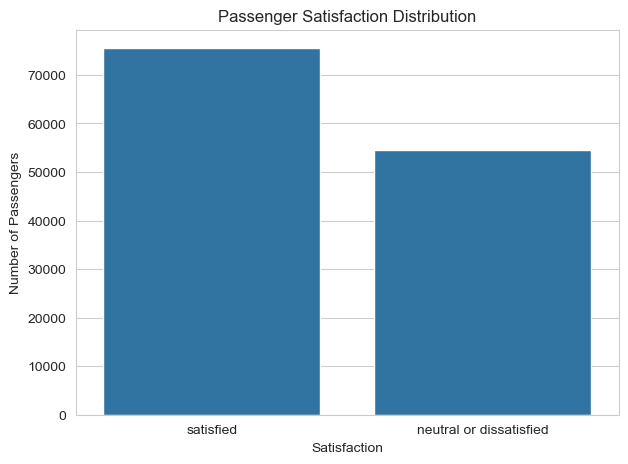

In [16]:
# Count the number of passengers in each satisfaction category
satisfaction_counts = df["satisfaction"].value_counts()

# Create the figure
plt.figure(figsize=(7, 5))

# Create a bar chart
sns.barplot(
    x=satisfaction_counts.index,
    y=satisfaction_counts.values
)

# Add chart title
plt.title("Passenger Satisfaction Distribution")

# Add x-axis label
plt.xlabel("Satisfaction")

# Add y-axis label
plt.ylabel("Number of Passengers")

# Display the chart
plt.show()

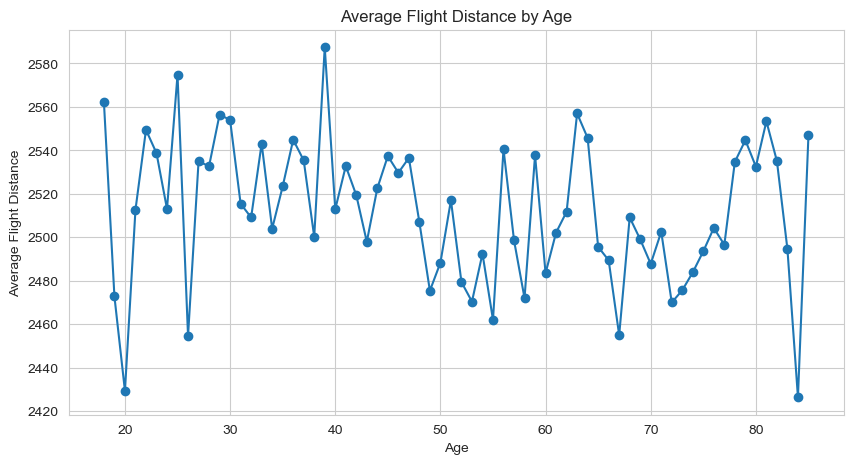

In [17]:
# Group passengers by age and calculate average flight distance
age_distance = df.groupby("age")["flight_distance"].mean()

# Create the figure
plt.figure(figsize=(10, 5))

# Create line chart
plt.plot(
    age_distance.index,
    age_distance.values,
    marker="o"
)

# Add title
plt.title("Average Flight Distance by Age")

# Add x-axis label
plt.xlabel("Age")

# Add y-axis label
plt.ylabel("Average Flight Distance")

# Display the chart
plt.show()

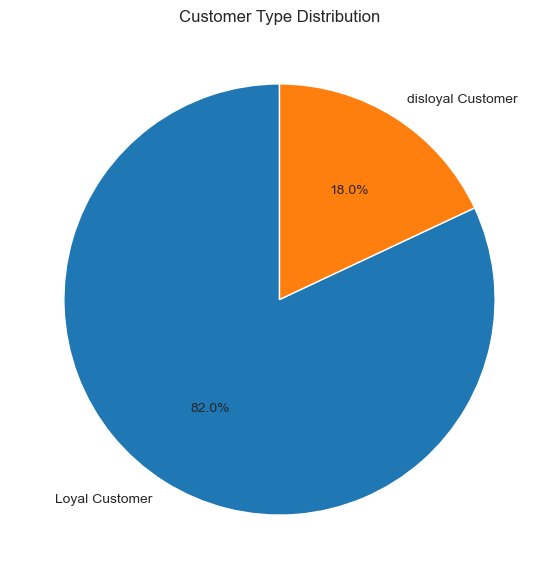

In [18]:
# Count passengers according to customer type
customer_type = df["customer_type"].value_counts()

# Create the figure
plt.figure(figsize=(7, 7))

# Create pie chart
plt.pie(
    customer_type.values,
    labels=customer_type.index,
    autopct="%1.1f%%",
    startangle=90
)

# Add title
plt.title("Customer Type Distribution")

# Display the chart
plt.show()

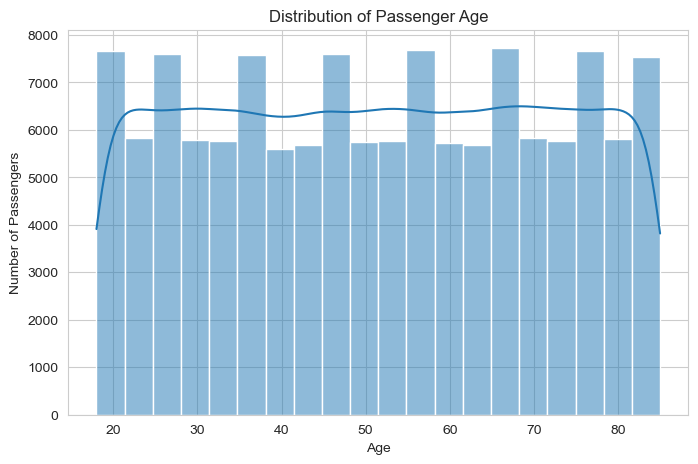

In [19]:
# Create the figure
plt.figure(figsize=(8, 5))

# Create histogram
sns.histplot(
    df["age"],
    bins=20,
    kde=True
)

# Add title
plt.title("Distribution of Passenger Age")

# Add x-axis label
plt.xlabel("Age")

# Add y-axis label
plt.ylabel("Number of Passengers")

# Display the chart
plt.show()

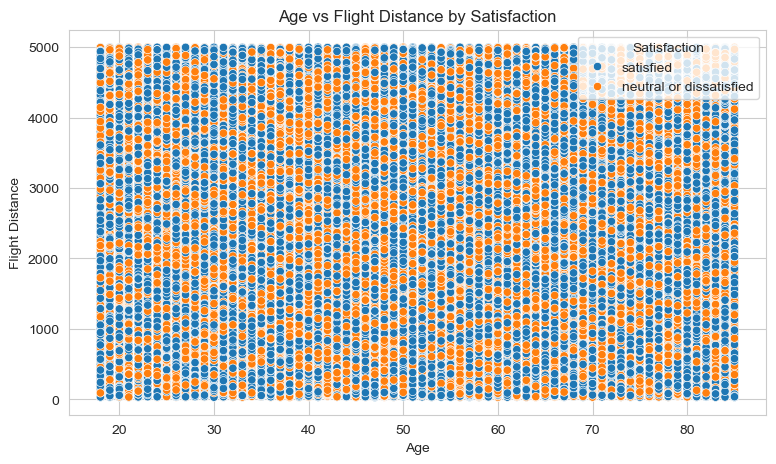

In [20]:
# Create the figure
plt.figure(figsize=(9, 5))

# Create scatter plot
sns.scatterplot(
    data=df,
    x="age",
    y="flight_distance",
    hue="satisfaction"
)

# Add title
plt.title("Age vs Flight Distance by Satisfaction")

# Add x-axis label
plt.xlabel("Age")

# Add y-axis label
plt.ylabel("Flight Distance")

# Set legend position manually
plt.legend(title="Satisfaction", loc="upper right")

# Display the chart
plt.show()

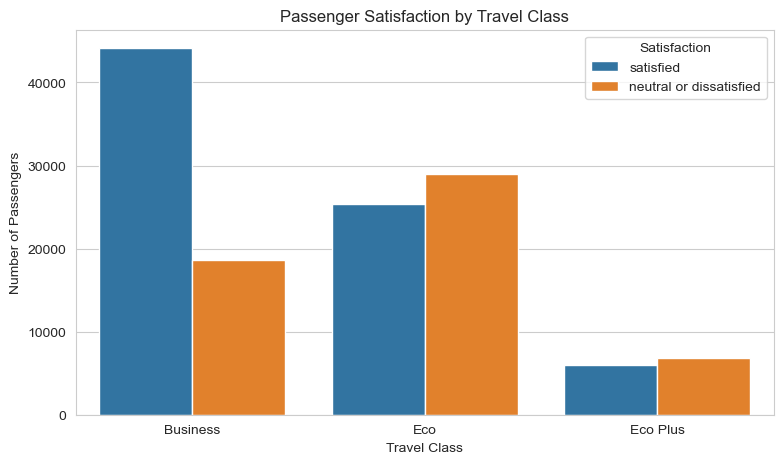

In [21]:
# Count satisfaction levels for each travel class
plt.figure(figsize=(9, 5))

# Create grouped bar chart
sns.countplot(
    data=df,
    x="class",
    hue="satisfaction"
)

# Add title
plt.title("Passenger Satisfaction by Travel Class")

# Add x-axis label
plt.xlabel("Travel Class")

# Add y-axis label
plt.ylabel("Number of Passengers")

# Display legend
plt.legend(title="Satisfaction")

# Display chart
plt.show()

## Customize charts with titles, labels, legends, and color schemes.

C:\Users\akash\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


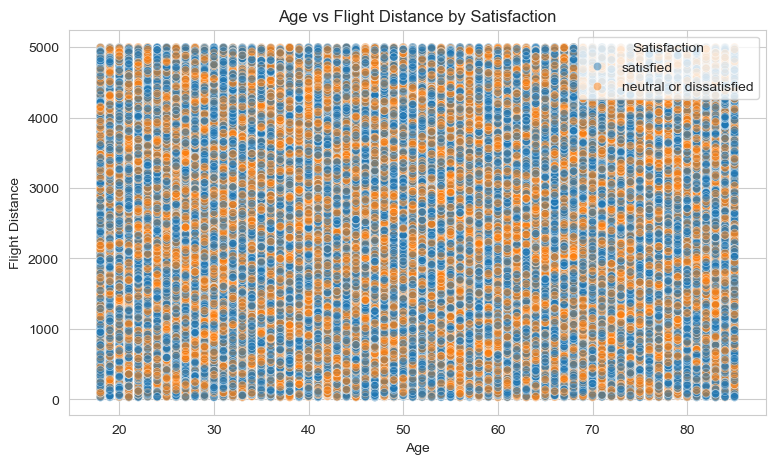

In [22]:
plt.figure(figsize=(9, 5))

sns.scatterplot(
    data=df,
    x="age",
    y="flight_distance",
    hue="satisfaction",
    alpha=0.5
)

plt.title("Age vs Flight Distance by Satisfaction")
plt.xlabel("Age")
plt.ylabel("Flight Distance")

# Get the existing legend and change its title
legend = plt.gca().get_legend()
legend.set_title("Satisfaction")

plt.show()

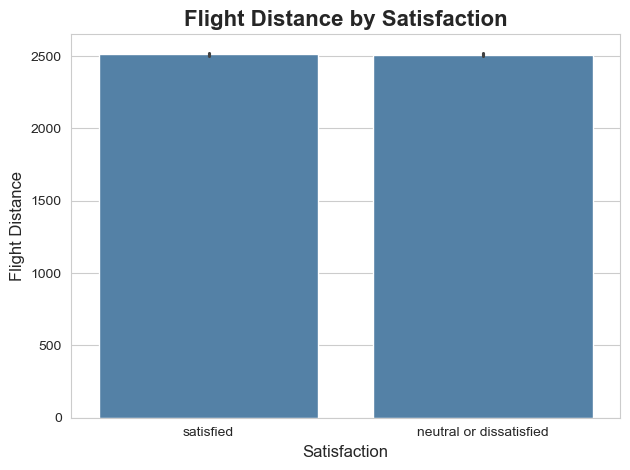

In [23]:
# Create bar chart with custom color
sns.barplot(
    data=df,
    x="satisfaction",
    y="flight_distance",
    color="steelblue"
)

# Customize title
plt.title("Flight Distance by Satisfaction", fontsize=16, fontweight="bold")

# Customize labels
plt.xlabel("Satisfaction", fontsize=12)
plt.ylabel("Flight Distance", fontsize=12)

# Display the chart
plt.tight_layout()
plt.show()

## Present insights through clear and easy-to-understand visualizations.

## Key Insights from Visualizations

- The bar chart clearly compares passenger satisfaction levels.
- The pie chart shows the proportion of different customer types.
- The histogram helps understand the age distribution of passengers.
- The line chart shows how average flight distance changes with passenger age.
- The scatter plot helps identify the relationship between age and flight distance.
- The visualizations make the dataset easier to understand and help identify useful patterns and trends.
- These insights can help airlines understand passenger behavior and improve customer satisfaction.